**AnalystLab Africa Data Science Internship**

**Objective:** Build multiple ML models (baseline, Decision Tree, Random Forest, Gradient Boosting), compare their performance, tune hyperparameters, and identify the best-performing model.


In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
BLUE, ORANGE, GREEN, RED, PURPLE, TEAL = '#2563EB','#F97316','#16A34A','#DC2626','#7C3AED','#0891B2'

housing = pd.read_csv(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_5_Project\Housing_Cleaned.csv")

In [93]:
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,furnishingstatus_enc
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,2


In [94]:
housing.shape

(545, 14)

###  Dataset Structure

In [95]:
housing.dtypes

price                   int64
area                    int64
bedrooms                int64
bathrooms               int64
stories                 int64
mainroad                int64
guestroom               int64
basement                int64
hotwaterheating         int64
airconditioning         int64
parking                 int64
prefarea                int64
furnishingstatus          str
furnishingstatus_enc    int64
dtype: object

In [96]:
housing.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_enc
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862,0.930275
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302,0.761373
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,2.000000


###  Handling Missing Values & Removing Duplicates

This dataset was already cleaned during Week 1 (median/mode imputation, no missing values, no duplicates). We verify this here before proceeding.

In [97]:
## Verifying Missing Values

housing.isnull().sum().to_frame(name="Missing values per column:")

,Missing values per column:
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [98]:
## Verifying duplicate Values

housing.duplicated().sum()

# Confirmed clean no further action needed

np.int64(0)

### Encoding Categorical Variables

Binary categorical columns (mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea) were already encoded as 0/1 in Week 1. `furnishingstatus` was ordinally encoded as `furnishingstatus_enc`.

In [99]:
# Categorical encoding already applied in Week 1

housing[['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [100]:
# Furnishing encoding: unfurnished=0, semi-furnished=1, furnished=2

housing[['furnishingstatus','furnishingstatus_enc']].drop_duplicates()

,furnishingstatus,furnishingstatus_enc
0,furnished,2
2,semi-furnished,1
7,unfurnished,0


### Selecting Features (X) and Target (y)

In [101]:
# Selecting Features (X) and Target (y)

features = [
    'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
    'guestroom', 'basement', 'hotwaterheating',
    'airconditioning', 'parking', 'prefarea',
    'furnishingstatus_enc'
]

X = housing[features]
y = housing['price']

dataset_summary = pd.DataFrame({
    "Dataset": ["Features (X)", "Target (y)"],
    "Shape": [X.shape, y.shape]
})

dataset_summary

,Dataset,Shape
0,Features (X),"(545, 12)"
1,Target (y),"(545,)"


### Train/Test Split

In [102]:
# Splitting the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

split_summary = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set"],
    "Samples": [len(X_train), len(X_test)],
    "Percentage": ["80%", "20%"],
    "Feature Shape": [X_train.shape, X_test.shape],
    "Target Shape": [y_train.shape, y_test.shape]
})

split_summary

,Dataset,Samples,Percentage,Feature Shape,Target Shape
0,Training Set,436,80%,"(436, 12)","(436,)"
1,Testing Set,109,20%,"(109, 12)","(109,)"


### Feature Scaling

Linear Regression benefits from feature scaling for stable, comparable coefficients. Tree-based models (Decision Tree, Random Forest, Gradient Boosting) are scale-invariant, so we use unscaled features for them and scaled features only for Linear Regression.

In [103]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaling_summary = pd.DataFrame({
    "Step": ["Feature Scaling"],
    "Training Data": ["Scaled using fit_transform()"],
    "Testing Data": ["Scaled using transform()"],
    "Note": ["Scaled features are used for Linear Regression; tree-based models use the original unscaled features."]
})

scaling_summary

,Step,Training Data,Testing Data,Note
0,Feature Scaling,Scaled using fit_transform(),Scaled using transform(),Scaled features are used for Linear Regression...


In [104]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Features scaled for Linear Regression. Tree-based models will use unscaled features.')

Features scaled for Linear Regression. Tree-based models will use unscaled features.


### Building a Baseline Model: Linear Regression

In [105]:
# Train the Linear Regression model

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

pred_lr = lr_model.predict(X_test_scaled)

# Model evaluation function
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE (£)": round(mae, 2),
        "MSE (£²)": round(mse, 2),
        "RMSE (£)": round(rmse, 2),
        "R² Score": round(r2, 4)
    }

results = {
    "Linear Regression (Baseline)": evaluate_model(y_test, pred_lr)
}

results_linear = pd.DataFrame(results).T

results_linear

,MAE (£),MSE (£²),RMSE (£),R² Score
Linear Regression (Baseline),979679.69,1.771751e+12,1331071.42,0.6495


### Training Advanced Machine Learning Models

### Decision Tree

In [106]:
# Training the Decision Tree model

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

pred_dt = dt_model.predict(X_test)

# Storing the evaluation metrics
results["Decision Tree"] = evaluate_model(y_test, pred_dt)

# Displaying the updated results table
results_decision = pd.DataFrame(results).T

results_decision

,MAE (£),MSE (£²),RMSE (£),R² Score
Linear Regression (Baseline),979679.69,1.771751e+12,1331071.42,0.6495
Decision Tree,1270788.99,2.951875e+12,1718102.24,0.4160


### Random Forest

In [107]:
# Train the Random Forest model

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)

# Store evaluation metrics
results["Random Forest"] = evaluate_model(y_test, pred_rf)

# Updated comparison table
results_random = pd.DataFrame(results).T

results_random

,MAE (£),MSE (£²),RMSE (£),R² Score
Linear Regression (Baseline),979679.69,1.771751e+12,1331071.42,0.6495
Decision Tree,1270788.99,2.951875e+12,1718102.24,0.4160
Random Forest,1024081.03,1.956925e+12,1398901.42,0.6128


In [108]:
# Comparing the Decision Tree and Random Forest

comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "RMSE (£)": [
        results["Decision Tree"]["RMSE (£)"],
        results["Random Forest"]["RMSE (£)"]
    ]
})

comparison_df["RMSE Improvement (£)"] = [
    np.nan,
    round(
        results["Decision Tree"]["RMSE (£)"] -
        results["Random Forest"]["RMSE (£)"],
        2
    )
]

comparison_df

,Model,RMSE (£),RMSE Improvement (£)
0,Decision Tree,1718102.24,NaN
1,Random Forest,1398901.42,319200.82


In [109]:
comparison_comment = pd.DataFrame({
    "Insight": [
        f"Random Forest reduced the RMSE by £{results['Decision Tree']['RMSE (£)'] - results['Random Forest']['RMSE (£)']:,.2f} compared to the Decision Tree, showing that combining multiple trees improved prediction accuracy and reduced overfitting."
    ]
})

comparison_comment

,Insight
0,"Random Forest reduced the RMSE by £319,200.82 ..."


### Gradient Boosting

In [110]:
# Train the Gradient Boosting model

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

pred_gb = gb_model.predict(X_test)

# Store the evaluation metrics
results["Gradient Boosting"] = evaluate_model(y_test, pred_gb)

# Display all model results
results_gradient = (
    pd.DataFrame(results)
    .T
    .sort_values(by="R² Score", ascending=False)
)

results_gradient

,MAE (£),MSE (£²),RMSE (£),R² Score
Gradient Boosting,963190.75,1.692331e+12,1300896.13,0.6652
Linear Regression (Baseline),979679.69,1.771751e+12,1331071.42,0.6495
Random Forest,1024081.03,1.956925e+12,1398901.42,0.6128
Decision Tree,1270788.99,2.951875e+12,1718102.24,0.4160


### Hyperparameter Tuning

We tune two models using GridSearchCV with 5-fold cross-validation: Random Forest and Gradient Boosting (our best baseline performer).

In [111]:
# Tuning Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)


best_params_df = pd.DataFrame(
    [grid_rf.best_params_],
    index=["Best Random Forest Parameters"]
)

best_params_df

best_rf = grid_rf.best_estimator_
pred_rf_tuned = best_rf.predict(X_test)

results["Random Forest (Tuned)"] = evaluate_model(
    y_test,
    pred_rf_tuned
)

results_best = (
    pd.DataFrame(results)
    .T
    .sort_values(by="R² Score", ascending=False)
)

results_best

,MAE (£),MSE (£²),RMSE (£),R² Score
Gradient Boosting,963190.75,1.692331e+12,1300896.13,0.6652
Linear Regression (Baseline),979679.69,1.771751e+12,1331071.42,0.6495
Random Forest,1024081.03,1.956925e+12,1398901.42,0.6128
Random Forest (Tuned),1045274.25,2.069163e+12,1438458.55,0.5906
Decision Tree,1270788.99,2.951875e+12,1718102.24,0.4160


In [112]:
best_params_df = pd.DataFrame(
    [grid_rf.best_params_],
    index=["Best Random Forest Parameters"]
)

best_params_df

,max_depth,min_samples_split,n_estimators
Best Random Forest Parameters,10,10,50


### Tuning Gradient Boosting

Since Gradient Boosting was our strongest baseline model, we also tune it varying `n_estimators`, `max_depth`, `learning_rate`, and `min_samples_split`.

In [113]:
param_grid_gb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_split': [2, 5, 10]
}

grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb, cv=5,
                        scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_gb.fit(X_train, y_train)

# Display the best hyperparameters
best_params_gb = pd.DataFrame(
    [grid_gb.best_params_],
    index=["Best Gradient Boosting Parameters"]
)

best_params_gb

# Evaluate the tuned model
best_gb = grid_gb.best_estimator_
pred_gb_tuned = best_gb.predict(X_test)

results["Gradient Boosting (Tuned)"] = evaluate_model(
    y_test,
    pred_gb_tuned
)

# Update the comparison table
results_grad = (
    pd.DataFrame(results)
    .T
    .sort_values(by="R² Score", ascending=False)
)

results_grad

,MAE (£),MSE (£²),RMSE (£),R² Score
Gradient Boosting,963190.75,1.692331e+12,1300896.13,0.6652
Linear Regression (Baseline),979679.69,1.771751e+12,1331071.42,0.6495
Gradient Boosting (Tuned),1002168.23,1.846646e+12,1358913.64,0.6347
Random Forest,1024081.03,1.956925e+12,1398901.42,0.6128
Random Forest (Tuned),1045274.25,2.069163e+12,1438458.55,0.5906
Decision Tree,1270788.99,2.951875e+12,1718102.24,0.4160


In [114]:
# Before vs After Tuning
# Comparing model performance before and after tuning

tuning_comparison = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "Default RMSE (£)": [
        results["Random Forest"]["RMSE (£)"],
        results["Gradient Boosting"]["RMSE (£)"]
    ],
    "Tuned RMSE (£)": [
        results["Random Forest (Tuned)"]["RMSE (£)"],
        results["Gradient Boosting (Tuned)"]["RMSE (£)"]
    ],
    "Default R²": [
        results["Random Forest"]["R² Score"],
        results["Gradient Boosting"]["R² Score"]
    ],
    "Tuned R²": [
        results["Random Forest (Tuned)"]["R² Score"],
        results["Gradient Boosting (Tuned)"]["R² Score"]
    ]
})

tuning_comparison["RMSE Change (£)"] = (
    tuning_comparison["Default RMSE (£)"] -
    tuning_comparison["Tuned RMSE (£)"]
).round(2)

tuning_comparison["Performance"] = tuning_comparison["RMSE Change (£)"].apply(
    lambda x: "Improved" if x > 0 else "Worsened"
)

tuning_comparison

,Model,Default RMSE (£),Tuned RMSE (£),Default R²,Tuned R²,RMSE Change (£),Performance
0,Random Forest,1398901.42,1438458.55,0.6128,0.5906,-39557.13,Worsened
1,Gradient Boosting,1300896.13,1358913.64,0.6652,0.6347,-58017.51,Worsened


In [115]:
tuning_summary = pd.DataFrame({
    "Summary": [
        f"Random Forest {tuning_comparison.loc[0, 'Performance'].lower()} by £{abs(tuning_comparison.loc[0, 'RMSE Change (£)']):,.2f}.",
        f"Gradient Boosting {tuning_comparison.loc[1, 'Performance'].lower()} by £{abs(tuning_comparison.loc[1, 'RMSE Change (£)']):,.2f}."
    ]
})

tuning_summary

,Summary
0,"Random Forest worsened by £39,557.13."
1,"Gradient Boosting worsened by £58,017.51."


**Important finding:** On this small dataset (545 rows, 109 test samples), GridSearchCV optimizes for cross-validation performance on the *training* folds, which does not always translate to better performance on the held-out test set. Both tuned models perform slightly *worse* on the test set than their defaults here a reminder that hyperparameter tuning is not guaranteed to help, especially on small datasets where CV folds carry high variance. The default Gradient Boosting model remains our best performer.

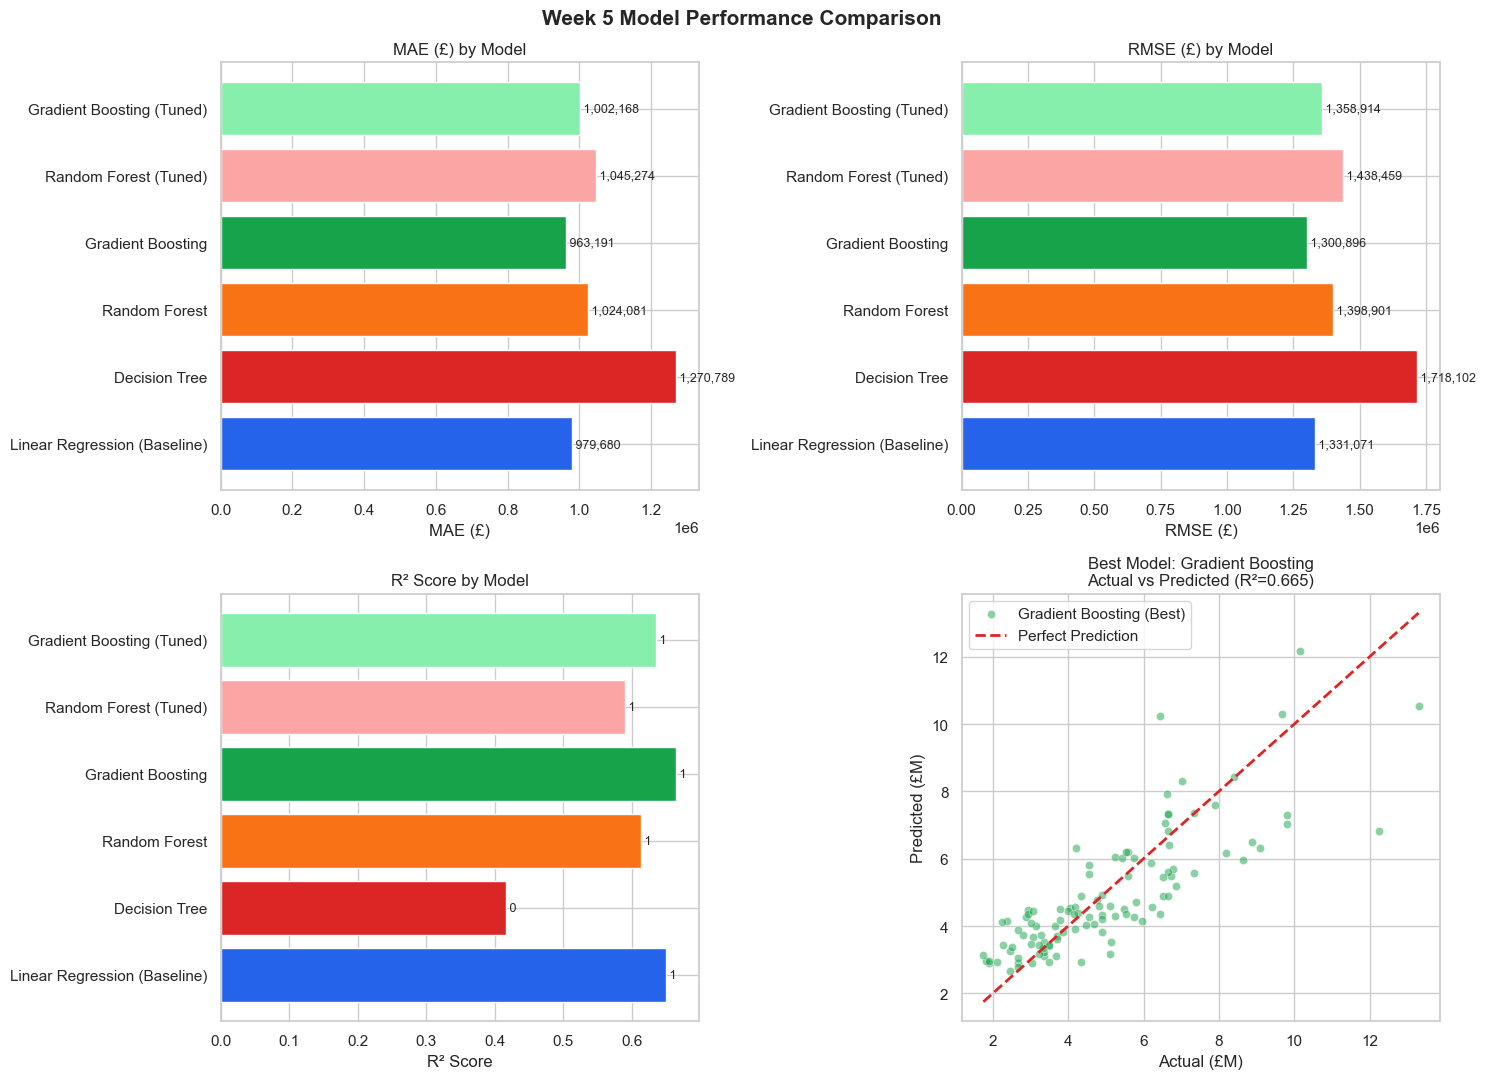

In [116]:
## Model Evaluation & Visualizations

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Week 5 Model Performance Comparison', fontsize=15, fontweight='bold')

model_names = list(results.keys())
colors_models = [BLUE, RED, ORANGE, GREEN, '#FCA5A5', '#86EFAC']

for i, metric in enumerate(['MAE (£)', 'RMSE (£)', 'R² Score']):
    ax = axes[i//2, i%2]
    vals = [results[m][metric] for m in model_names]
    bars = ax.barh(model_names, vals, color=colors_models[:len(model_names)], edgecolor='white')
    ax.set_title(f'{metric} by Model')
    ax.set_xlabel(metric)
    for bar in bars:
        w = bar.get_width()
        label = f'{w:,.0f}' if metric != 'R2' else f'{w:.3f}'
        ax.text(w, bar.get_y()+bar.get_height()/2, f' {label}', va='center', fontsize=9)

ax = axes[1,1]
ax.scatter(y_test/1e6, pred_gb/1e6, alpha=0.5, color=GREEN, s=35, edgecolors='white', linewidth=0.5, label='Gradient Boosting (Best)')
mn, mx = min(y_test.min(), pred_gb.min())/1e6, max(y_test.max(), pred_gb.max())/1e6
ax.plot([mn,mx],[mn,mx], color=RED, linewidth=2, linestyle='--', label='Perfect Prediction')
ax.set_title(
    f'Best Model: Gradient Boosting\nActual vs Predicted (R²={results["Gradient Boosting"]["R² Score"]:.3f})'
)
ax.set_xlabel('Actual (£M)'); ax.set_ylabel('Predicted (£M)'); ax.legend()

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_5_Project\plot1.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

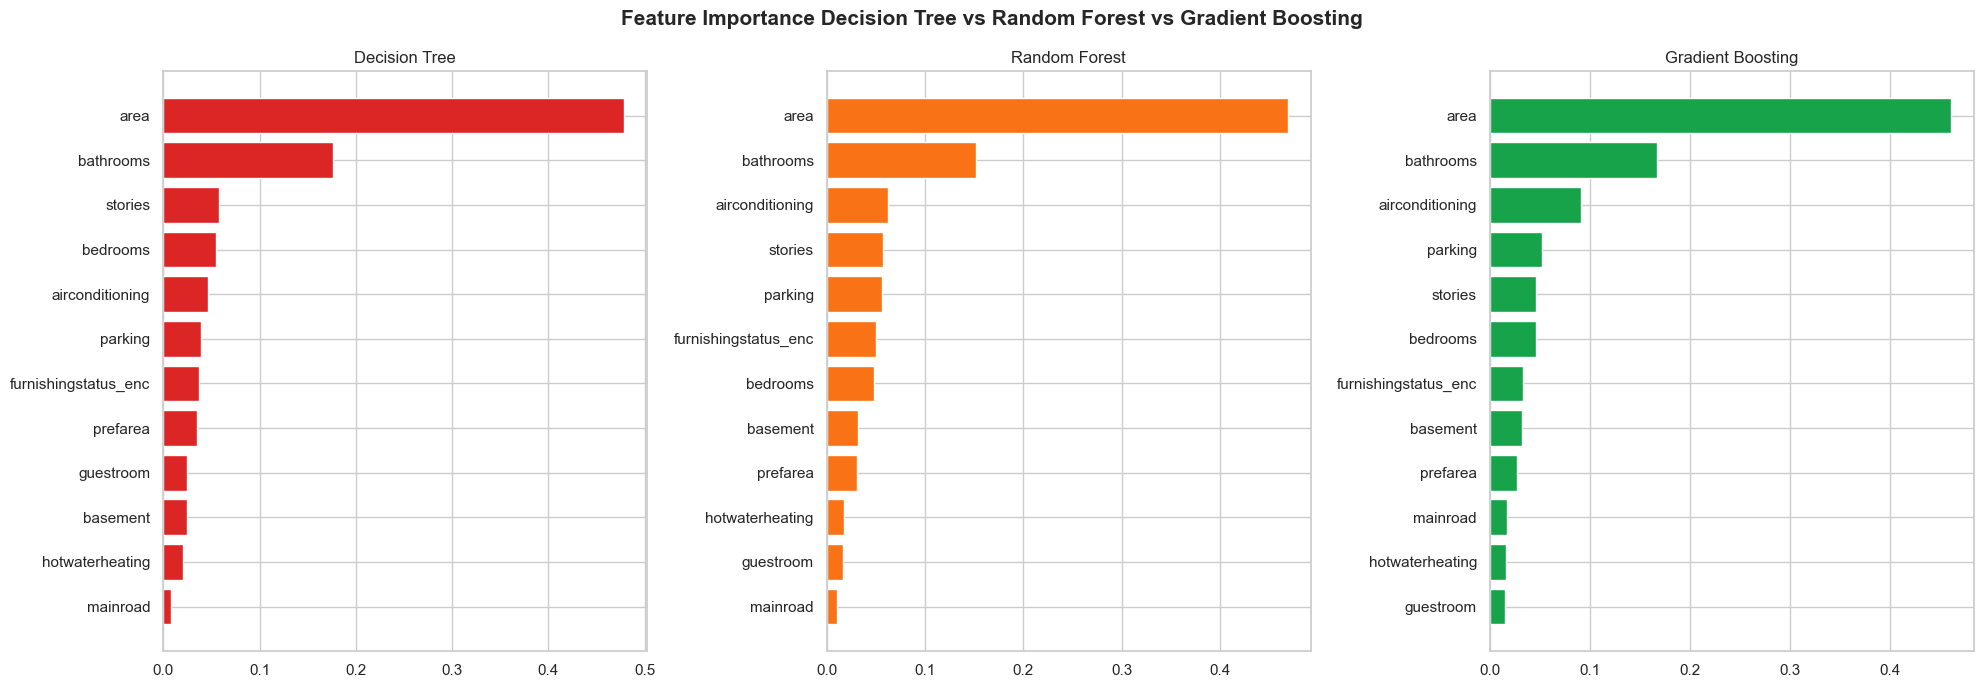

In [117]:
#  Feature Importance Comparison 

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Feature Importance Decision Tree vs Random Forest vs Gradient Boosting', fontsize=15, fontweight='bold')

fi_dt = pd.Series(dt_model.feature_importances_, index=features).sort_values()
fi_rf = pd.Series(rf_model.feature_importances_, index=features).sort_values()
fi_gb = pd.Series(gb_model.feature_importances_, index=features).sort_values()

axes[0].barh(fi_dt.index, fi_dt.values, color=RED, edgecolor='white')
axes[0].set_title('Decision Tree')

axes[1].barh(fi_rf.index, fi_rf.values, color=ORANGE, edgecolor='white')
axes[1].set_title('Random Forest')

axes[2].barh(fi_gb.index, fi_gb.values, color=GREEN, edgecolor='white')
axes[2].set_title('Gradient Boosting')

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_5_Project\plot2.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

In [118]:
results["Random Forest"]


{'MAE (£)': 1024081.03,
 'MSE (£²)': 1956925181711.52,
 'RMSE (£)': np.float64(1398901.42),
 'R² Score': 0.6128}

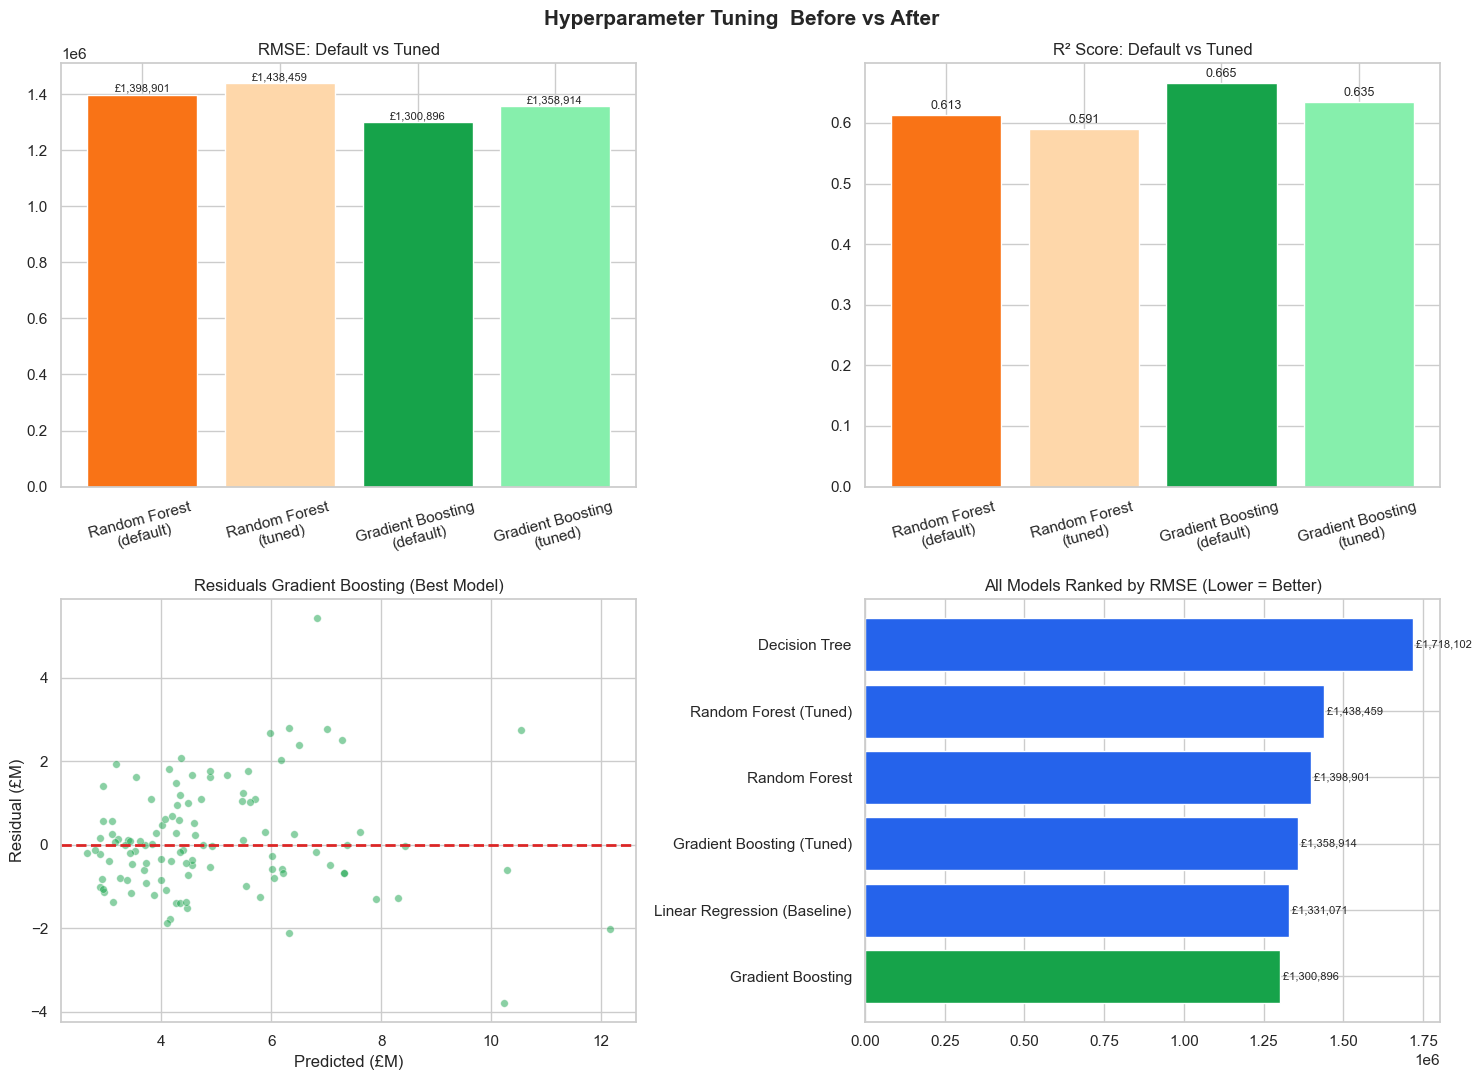

In [119]:
#  Tuning impact + residuals + ranked comparison 

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Hyperparameter Tuning  Before vs After', fontsize=15, fontweight='bold')

labels = ['Random Forest\n(default)', 'Random Forest\n(tuned)', 'Gradient Boosting\n(default)', 'Gradient Boosting\n(tuned)']
vals = [
    results['Random Forest']['RMSE (£)'],
    results['Random Forest (Tuned)']['RMSE (£)'],
    results['Gradient Boosting']['RMSE (£)'],
    results['Gradient Boosting (Tuned)']['RMSE (£)']
]
ax = axes[0,0]
bars = ax.bar(labels, vals, color=[ORANGE,'#FED7AA',GREEN,'#86EFAC'], edgecolor='white')
ax.set_title('RMSE: Default vs Tuned'); ax.tick_params(axis='x', rotation=15)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10000, f'£{bar.get_height():,.0f}', ha='center', fontsize=8)

vals_r2 = [
    results['Random Forest']['R² Score'],
    results['Random Forest (Tuned)']['R² Score'],
    results['Gradient Boosting']['R² Score'],
    results['Gradient Boosting (Tuned)']['R² Score']
]
ax = axes[0,1]
bars = ax.bar(labels, vals_r2, color=[ORANGE,'#FED7AA',GREEN,'#86EFAC'], edgecolor='white')
ax.set_title('R² Score: Default vs Tuned'); ax.tick_params(axis='x', rotation=15)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax = axes[1,0]
residuals_gb = y_test - pred_gb
ax.scatter(pred_gb/1e6, residuals_gb/1e6, alpha=0.5, color=GREEN, s=30, edgecolors='white', linewidth=0.5)
ax.axhline(0, color=RED, linewidth=2, linestyle='--')
ax.set_title('Residuals Gradient Boosting (Best Model)')
ax.set_xlabel('Predicted (£M)'); ax.set_ylabel('Residual (£M)')

ax = axes[1,1]
all_names = list(results.keys())
all_rmse = [results[n]['RMSE (£)'] for n in all_names]
sorted_idx = np.argsort(all_rmse)
sorted_names = [all_names[i] for i in sorted_idx]
sorted_rmse = [all_rmse[i] for i in sorted_idx]
bars = ax.barh(sorted_names, sorted_rmse, color=[GREEN if i==0 else BLUE for i in range(len(sorted_names))], edgecolor='white')
ax.set_title('All Models Ranked by RMSE (Lower = Better)')
for bar in bars:
    ax.text(bar.get_width(), bar.get_y()+bar.get_height()/2, f' £{bar.get_width():,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_5_Project\plot3.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

### Performance Comparison Table

In [120]:
comparison_housing = (
    pd.DataFrame(results)
    .T[['MAE (£)', 'MSE (£²)', 'RMSE (£)', 'R² Score']]
    .sort_values(by='RMSE (£)')
    .round(2)
)

comparison_housing

,MAE (£),MSE (£²),RMSE (£),R² Score
Gradient Boosting,963190.75,1.692331e+12,1300896.13,0.67
Linear Regression (Baseline),979679.69,1.771751e+12,1331071.42,0.65
Gradient Boosting (Tuned),1002168.23,1.846646e+12,1358913.64,0.63
Random Forest,1024081.03,1.956925e+12,1398901.42,0.61
Random Forest (Tuned),1045274.25,2.069163e+12,1438458.55,0.59
Decision Tree,1270788.99,2.951875e+12,1718102.24,0.42


### Best-Performing Model: Gradient Boosting (default parameters)

| Model | MAE | RMSE | R² |
|-------|-----|------|-----|
| **Gradient Boosting** | £963,191 | **£1,300,896** | **0.6652** |
| Linear Regression (Baseline) | £979,680 | £1,331,071 | 0.6495 |
| Gradient Boosting (Tuned) | £1,002,168 | £1,358,914 | 0.6347 |
| Random Forest | £1,024,081 | £1,398,901 | 0.6128 |
| Random Forest (Tuned) | £1,045,274 | £1,438,459 | 0.5906 |
| Decision Tree | £1,270,789 | £1,718,102 | 0.4160 |

**Why Gradient Boosting (default) performed best:**

- **Sequential error correction**: Gradient Boosting builds trees sequentially, with each new tree specifically targeting the residual errors of the previous ones this lets it capture subtle, non-linear patterns (like the bathroom and AC price premiums found in EDA) more precisely than a single Linear Regression line.
- **Outperforms Random Forest**: Unlike Random Forest's parallel, independent trees, Gradient Boosting's sequential refinement is more sample-efficient valuable on a dataset of only 545 rows where Random Forest has less data per tree to learn robust splits.
- **Outperforms Decision Tree by a wide margin**: A single Decision Tree (R²=0.42) overfits to training noise and fails to generalize; both ensemble methods (RF, GB) correct for this by combining multiple trees.
- **Beats its own tuned version**: This is the most instructive finding. With only 436 training rows, 5-fold CV folds become small (~87 rows each), making the tuning process noisy and prone to selecting hyperparameters that overfit the validation folds rather than generalizing to the true test set. This demonstrates that **hyperparameter tuning is not automatically beneficial** it must be validated against held-out test performance, not assumed.

---
## Conclusions

1. **Gradient Boosting (default settings) is the best-performing model** for this house price prediction task, achieving the lowest RMSE (£1,300,896) and highest R² (0.6652) among all six models tested.

2. **Linear Regression remains a strong, simple baseline** its R²=0.65 is only marginally behind Gradient Boosting, demonstrating that the underlying price relationships in this dataset are largely linear or near-linear, given the engineered binary/ordinal features.

3. **Random Forest outperforms a single Decision Tree substantially** (R²=0.61 vs 0.42), confirming the value of ensembling even before any tuning averaging across many trees reduces the overfitting that a single deep tree is prone to.

4. **Hyperparameter tuning did not improve test performance** for either Random Forest or Gradient Boosting on this dataset. This is an important, honest finding: with only 545 total rows, cross-validation folds are small and noisy, and GridSearchCV optimized for in-sample CV performance rather than true generalization. This is a key lesson for working with small datasets more data or repeated/nested cross-validation would likely be needed to get reliable tuning gains.

5. **Feature importance is consistent across tree-based models** Area and Bathrooms are consistently ranked as the top two most important features across Decision Tree, Random Forest, and Gradient Boosting, reinforcing the findings from Week 1-2 EDA and Week 4's Linear Regression coefficients.

6. **Recommendation**: Deploy the default Gradient Boosting model as the production model for this task. If more data becomes available in future weeks, revisit hyperparameter tuning with nested cross-validation or a larger held-out validation set to obtain more reliable tuning gains.